In [1]:
import pandas as pd
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os
import h5py
import glob
import numpy as np
import yaml

In [2]:
file_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/fit_res.npz'
gain_file = np.load(file_path)

file2_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/adc2024_breakdown_overv.npz'
f_2024 = np.load(file2_path)

file3_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/3110/fit_res_v06_10dB.npz'
#file3_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/0411/fit_res_0411_v21_10dB.npz'
f_10dB_1pe = np.load(file3_path)

file4_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/0411/fit_res_0411_v24_10dB.npz'
f_10dB_npe = np.load(file4_path)

file5_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/0411/fit_res_0411_v25_10dB.npz'
f_10dB_sum = np.load(file5_path)

file6_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/Co60_tests/fit_res_Co60_v01_10dB_50tick.npz'
f_10dB_Co60_50tick = np.load(file6_path)

file7_path = '/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/Co60_tests/fit_res_Co60_v01_10dB_25tick.npz'
f_10dB_Co60_25tick = np.load(file7_path)

In [3]:
print(np.shape(gain_file['bdv_value']))
print(np.shape(f_2024['data']))

(8, 64)
(8, 64, 2)


In [4]:
with open('/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/AFIViewer/WaveformCalib_Mod0Estimates.yaml', 'r') as file:
    data = yaml.safe_load(file)

# Access the gain dictionary
gain_dict = data['params']['gain']

channels = ([4,5,6,7,8,9] + \
            [10,11,12,13,14,15] + \
            [20,21,22,23,24,25] + \
            [26,27,28,29,30,31] + \
            [36,37,38,39,40,41] + \
            [42,43,44,45,46,47] + \
            [52,53,54,55,56,57] + \
            [58,59,60,61,62,63])

# Initialize empty array
gain_array = np.zeros((8, 48))

# Fill the array
for row in range(8):
    for col_idx, channel in enumerate(channels):
        gain_array[row, col_idx] = gain_dict.get(row, {}).get(channel, 0.0)

print(gain_array.shape)  # (8, 48)


(8, 48)


In [5]:
gain_data = gain_file['bdv_value'][:,channels]
print(np.shape(gain_data))
print(gain_data)
#gain_mask = (gain_data < 50)
#subtraction = gain_mask - 300
#subbed_gain = gain_data #+ subtraction*gain_mask

gain2_data = f_2024['data'][:,channels,0]
print(np.shape(gain2_data))
#gain2_mask = (gain2_data < 50)
#subtraction2 = gain2_mask - 300
#subbed_gain2 = gain2_data #+ subtraction*gain_mask

gain10dB_1pe_data = f_10dB_1pe['bdv_value'][:,channels]
print(np.shape(gain10dB_1pe_data))

gain10dB_npe_data = f_10dB_npe['bdv_value'][:,channels]
print(np.shape(gain10dB_npe_data))

gain10dB_sum_data = f_10dB_sum['bdv_value'][:,channels]
print(np.shape(gain10dB_sum_data))

gain10dB_Co60_50tick_data = f_10dB_Co60_50tick['bdv_value'][:,channels]
print(np.shape(gain10dB_Co60_50tick_data))

gain10dB_Co60_25tick_data = f_10dB_Co60_25tick['bdv_value'][:,channels]
print(np.shape(gain10dB_Co60_25tick_data))

(8, 48)
[[  39.34   40.59   36.78   45.68   37.7    39.27   41.71  -65.33   40.33
    41.     42.78   40.71    0.     39.68   39.54   40.35   38.68   39.63
    36.33   40.07   40.95   39.44   39.74   39.45   39.4    39.79   40.68
  -212.39   38.64   40.5    40.36   39.78   39.07   40.77   39.14   39.35
    40.27   36.68   40.95   39.83   40.37   40.42   40.27   40.76   40.15
    40.36   40.62   53.37]
 [  39.17   36.83   38.17   40.03   38.29   39.1    39.75   33.64   39.18
    40.29   40.36   40.13   40.58   40.32   40.31   40.11   40.47   37.55
    40.08   21.05   36.49   39.96   40.22   37.08   38.59   41.05   39.08
    35.17   35.89   40.31   36.22 -427.12   40.     38.8    36.03   41.65
    41.18   32.27   38.74   39.01   38.52   35.7    39.76   41.35   40.06
    39.72   41.04   41.  ]
 [  41.74   41.97   42.24   41.86   41.59   41.71   41.76   41.56    0.
    41.69   41.61   41.89   41.87   41.68    0.     41.52   41.66   41.71
    42.21   42.18   41.93   41.9    42.06   41.84   

In [6]:
dead_array = [np.array([7,10,20]),
                np.array([]),
                np.array([22,54]),
                np.array([27,61]),
                np.array([4,15,36,47]),
                np.array([37]),
                np.array([14,15,20,21,22,23,46,47,52,53,54,55]),
                np.array([4,15])]

sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])

new_dead_array = np.ones((8,48))
for i in range(8):
    for j in range(48):
        if len(dead_array[i]) > 0:
            for k in dead_array[i]:
                loc_48 = np.where(sipm_channels == k)[0][0]
                new_dead_array[i,loc_48] *= 0

ModeResult(mode=0.006431, count=48)
ModeResult(mode=0.005243, count=48)
ModeResult(mode=0.0016895, count=2)
ModeResult(mode=0.0016493, count=2)
ModeResult(mode=0.0017056, count=2)
ModeResult(mode=0.0014475, count=1)
ModeResult(mode=0.0019862, count=4)
ModeResult(mode=0.0015294, count=3)


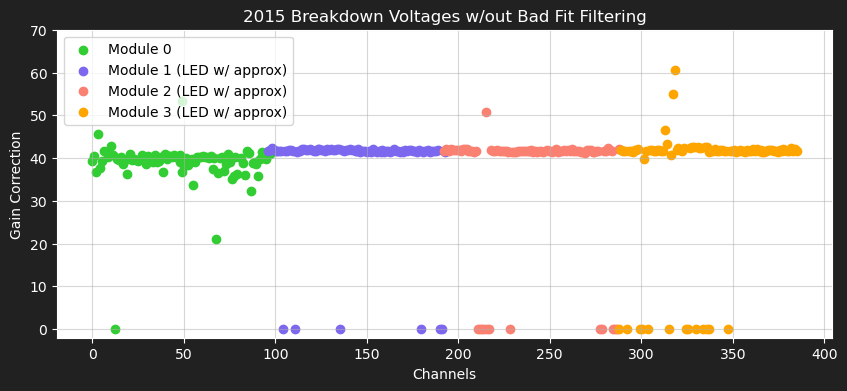

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
from scipy import stats
print(stats.mode(gain_array[0]))
print(stats.mode(gain_array[1]))
print(stats.mode(gain_array[2]))
print(stats.mode(gain_array[3]))
print(stats.mode(gain_array[4]))
print(stats.mode(gain_array[5]))
print(stats.mode(gain_array[6]))
print(stats.mode(gain_array[7]))
colors = ['limegreen', 'limegreen', 'mediumslateblue', 'mediumslateblue', 'salmon', 'salmon', 'orange', 'orange']
labels = ['Module 0 (Hand-calibrated)', 'Module 0', 'Module 1', 'Module 1 (LED w/ approx)', 'Module 2', 'Module 2 (LED w/ approx)', 'Module 3', 'Module 3 (LED w/ approx)']
original_list = [0,1,2,3,4,5,6,7]
#hand_scan_0 = np.zeros(48) - 300
#hand_scan_1 = np.zeros(48) - 300
#idx_31 = np.where(np.array(channels)==31)[0]
#idx_55 = np.where(np.array(channels)==55)[0]
#hand_scan_1[idx_55] += (300 + 1 / gain_array[1,idx_55])
#hand_scan_0[idx_31] += (300 + 1 / gain_array[0,idx_31])
for adc in original_list:
    factor = adc*48
    if (adc%2)==1:
        ax.scatter(np.linspace(0+factor,49+factor, 48), gain_data[adc,:], color=colors[adc], label=labels[adc])
    else:
        ax.scatter(np.linspace(0+factor,49+factor,48), gain_data[adc,:], color=colors[adc])
#ax.scatter(np.linspace(0,49,48), hand_scan_0, color=colors[0], label=labels[0])
#ax.scatter(np.linspace(48,49+48,48), hand_scan_1, color=colors[0])
fig.patch.set_facecolor('#212121')
ax.set_xlabel('Channels', color='white')
ax.set_ylabel('Gain Correction', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.set_ylim(-2,70)
ax.set_title('2015 Breakdown Voltages w/out Bad Fit Filtering', color='white')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


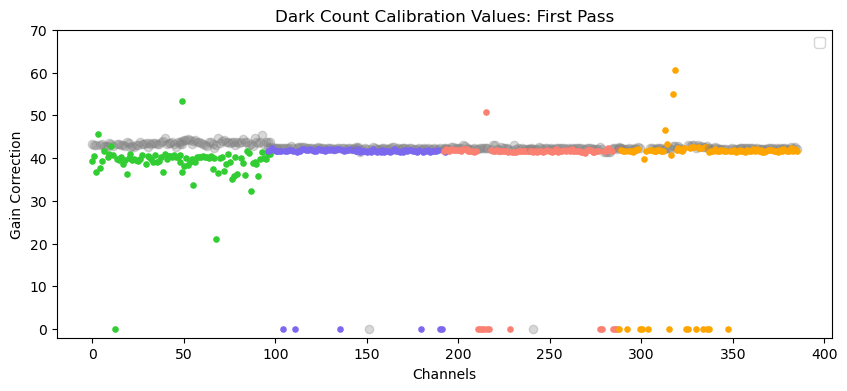

In [8]:
fig, ax = plt.subplots(figsize=(10,4))
colors = ['limegreen', 'limegreen', 'mediumslateblue', 'mediumslateblue', 'salmon', 'salmon', 'orange', 'orange']
labels = ['Module 0', 'Module 0', 'Module 1', 'Module 1', 'Module 2', 'Module 2', 'Module 3', 'Module 3']
original_list = [0,1,2,3,4,5,6,7]
#hand_scan_0 = np.zeros(48) - 300
#hand_scan_1 = np.zeros(48) - 300
#idx_31 = np.where(np.array(channels)==31)[0]
#idx_55 = np.where(np.array(channels)==55)[0]
#hand_scan_1[idx_55] += (300 + 1 / gain_array[1,idx_55])
#hand_scan_0[idx_31] += (300 + 1 / gain_array[0,idx_31])
for adc in original_list:
    factor = adc*48
    #if adc==0: 
    #    ax.scatter(np.linspace(0,49,48), hand_scan_0, color='grey', alpha=0.4)
    #    ax.scatter(np.linspace(0+factor,49+factor, 48), subbed_gain[adc,:], s=14, color=colors[adc], label=labels[adc])
    #elif adc==1:
    #    ax.scatter(np.linspace(48,49+48,48), hand_scan_1, color='grey', alpha=0.4) 
    #    ax.scatter(np.linspace(0+factor,49+factor,48), subbed_gain[adc,:], s=14, color=colors[adc])
    #else: 
    #if (adc%2)==1:
    #        ax.scatter(np.linspace(0+factor,49+factor, 48), gain_data[adc,:], color='grey', alpha=0.4)
    #        ax.scatter(np.linspace(0+factor,49+factor, 48), gain_data[adc,:], s=14, color=colors[adc], label=labels[adc])
    #else:
    ax.scatter(np.linspace(0+factor,49+factor, 48), gain2_data[adc,:], color='grey', alpha=0.3)
    ax.scatter(np.linspace(0+factor,49+factor,48), gain_data[adc,:], s=14, color=colors[adc])
ax.set_xlabel('Channels')
ax.set_ylabel('Gain Correction')
ax.set_ylim(-2,70)
ax.set_title('Dark Count Calibration Values: First Pass')
plt.legend()
plt.show()

(8, 48)
44.33298611111111


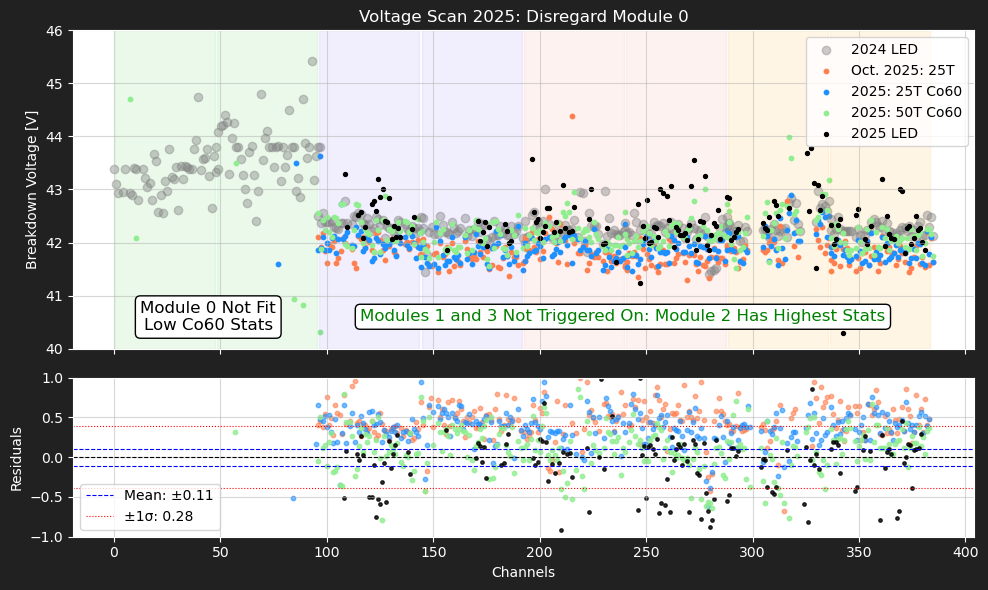

In [32]:
#hand_scan_t0 = np.zeros(48)
#hand_scan_t1 = np.zeros(48)
##idx_31 = np.where(np.array(channels)==31)[0]
#idx_55 = np.where(np.array(channels)==55)[0]
#hand_scan_tt1 = hand_scan_t1 + 1 / gain_array[1,idx_55]
##hand_scan_tt0 = hand_scan_t0 + 1 / gain_array[0,idx_31]
#led_channels = [[],[],np.array([18,19,20]),np.array([28,32]),[],np.array([13,21]),np.array([32,33,35,36,37,46]),[]]
#led_values = [[],[],np.array([42.51,42.57,42.09]),np.array([42.11,42.1]),[],np.array([42.18,42.44]),np.array([42.7,42.7,42.64,42.67,42.51,42.79]),[]]
led_data = np.load("/global/cfs/cdirs/dune/users/sallinn/data/2x2_calib/test/20251104_Vbr_LED.npz")
V_br_LED = led_data["Vbr_LED"][:, channels]
print(np.shape(V_br_LED))

# --- Calculate residuals (difference between old and new values)
residuals_self = []
residuals_24 = []
residuals_101 = []
residuals_10N = []
residuals_LED = []
residuals_sum = []
residuals_tick = []
residuals_50 = []
for adc in original_list:
    #if adc == 0:
    #    residual = hand_scan_tt0 - subbed_gain[adc, :]
    #elif adc == 1:
    #    residual = hand_scan_tt1 - subbed_gain[adc, :]
    #else:
    #residual = (gain2_data[adc, :]) - gain10dB_data[adc, :]
    residual_s = (gain2_data[adc, :]) - gain2_data[adc, :]
    residuals_self.append(residual_s)

    residual_24 = (gain2_data[adc, :]) - gain_data[adc, :]
    residuals_24.append(residual_24)

    residual_101 = (gain2_data[adc, :]) - gain10dB_1pe_data[adc, :]
    residuals_101.append(residual_101)

    residual_10N = (gain2_data[adc, :]) - (gain10dB_npe_data[adc, :])#+0.46
    residuals_10N.append(residual_10N)

    residual_LED = (gain2_data[adc, :]) - V_br_LED[adc, :]
    residuals_LED.append(residual_LED)

    residual_sum = (gain2_data[adc, :]) - gain10dB_sum_data[adc, :]
    residuals_sum.append(residual_sum)

    residual_tick = (gain2_data[adc, :]) - gain10dB_Co60_25tick_data[adc, :]
    residuals_tick.append(residual_tick)

    residual_50 = (gain2_data[adc, :]) - gain10dB_Co60_50tick_data[adc, :]
    residuals_50.append(residual_50)

residuals_self = np.concatenate(residuals_self)  # Shape: (384,)
residuals_24 = np.concatenate(residuals_24)
residuals_101 = np.concatenate(residuals_101)
residuals_10N = np.concatenate(residuals_10N)
residuals_LED = np.concatenate(residuals_LED)
residuals_sum = np.concatenate(residuals_sum)
residuals_tick = np.concatenate(residuals_tick)
residuals_50 = np.concatenate(residuals_50)

# --- Create figure with two subplots
fig, (ax_main, ax_resid) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Plot main gain calibration values
for adc in original_list:
    factor = adc * 48
    x_vals = np.linspace(factor, factor + 49, 48)
    #if adc == 0:
    #    ax_main.scatter(np.linspace(0, 49, 48), hand_scan_0, color='grey', alpha=0.4)
    #    ax_main.scatter(x_vals, subbed_gain[adc, :], s=14, color=colors[adc], label=labels[adc])
    #elif adc == 1:
    #    ax_main.scatter(np.linspace(48, 97, 48), hand_scan_1, color='grey', alpha=0.4)
    #    ax_main.scatter(x_vals, subbed_gain[adc, :], s=14, color=colors[adc])
    ax_main.axvspan(factor+0.5, factor+47.5, color=colors[adc], alpha=0.1)
    #else:
    ax_main.scatter(x_vals, gain2_data[adc, :]*new_dead_array[adc,:], color='grey', alpha=0.4, label='2024 LED' if adc == 0 else None)
    #ax_main.scatter(x_vals, gain_data[adc, :], color='lightblue', alpha=0.4,  label='2025 24dB' if adc == 0 else None)
    #ax_main.scatter(x_vals, gain_data[adc, :], s=14, color=colors[adc], label=labels[adc] if adc % 2 == 1 else None)
    #ax_main.scatter(x_vals, gain10dB_1pe_data[adc, :], s=14, color='green', alpha=0.4, label='2025 10dB: 1pe' if adc == 0 else None)

    #ax_main.scatter(x_vals, gain10dB_npe_data[adc, :]+0.42, s=14, color='lightblue', alpha=1, label='2025: np.trapz' if adc == 0 else None)

    #ax_main.scatter(x_vals, gain10dB_npe_data[adc,:]*new_dead_array[adc,:]+0.42, color='coral', alpha=1, s=10, label='2025: Low-Light' if adc == 6 else None)
    ax_main.scatter(x_vals, gain10dB_npe_data[adc,:]*new_dead_array[adc,:], color='coral', alpha=1, s=10, label='Oct. 2025: 25T' if adc == 6 else None)
    #if adc==4:
    ax_main.scatter(x_vals, gain10dB_Co60_25tick_data[adc,:]*new_dead_array[adc,:], color='dodgerblue', alpha=1, s=10, label='2025: 25T Co60' if adc == 6 else None)
    ax_main.scatter(x_vals, gain10dB_Co60_50tick_data[adc,:]*new_dead_array[adc,:], color='lightgreen', alpha=1, s=10, label='2025: 50T Co60' if adc == 6 else None)

    #if adc==5:
    #    ax_main.scatter(x_vals, gain10dB_Co60_50tick_data[adc,:]*new_dead_array[adc,:], color='lightgreen', alpha=1, s=10, label='2025: 50T Co60' if adc == 5 else None)
    #    ax_main.scatter(x_vals, gain10dB_Co60_25tick_data[adc,:]*new_dead_array[adc,:], color='dodgerblue', alpha=1, s=10, label='2025: 25T Co60' if adc == 5 else None)
    #print(gain10dB_Co60_data[adc,:])
    
    #if len(led_channels[adc]) > 0:
    ax_main.scatter(x_vals, V_br_LED[adc,:], color='k', alpha=1, s=8, label='2025 LED' if adc == 6 else None)

ax_main.set_ylabel("Breakdown Voltage [V]", color='white')
ax_main.set_ylim(40, 46)
ax_main.set_title("Voltage Scan 2025: Disregard Module 0", color='white')
fig.patch.set_facecolor('#212121')
ax_main.tick_params(colors='white')
for spine in ax_main.spines.values():
    spine.set_color('white')
ax_main.grid(True, alpha=0.5)
ax_main.legend(loc='upper right')

# --- Plot residuals
channel_indices = np.arange(384)
# Assign colors per 96-channel block
color_map = ['limegreen'] * 96 + ['mediumslateblue'] * 96 + ['salmon'] * 96 + ['orange'] * 96
#ax_resid.scatter(channel_indices, residuals, c=color_map, s=10)
#ax_resid.scatter(channel_indices, residuals_self, c='grey', alpha=0.4, s=10)
#ax_resid.scatter(channel_indices, residuals_24, c='lightblue', alpha=0.4, s=10)
#ax_resid.scatter(channel_indices, residuals_101, c='green', alpha=0.4, s=10)
ax_resid.scatter(channel_indices, residuals_10N, c='coral', alpha=0.6, s=10)
ax_resid.scatter(channel_indices, residuals_tick, c='dodgerblue', alpha=0.6, s=10)
ax_resid.scatter(channel_indices, residuals_50, c='lightgreen', alpha=0.8, s=10)
ax_resid.scatter(channel_indices, residuals_LED, c='k', alpha=0.8, s=6)

# Optional: add mean & std lines
print(np.mean(residuals_50[96:]))
mean_resid = np.mean(residuals_50[96:][np.abs(residuals_50[96:]) < 1])
std_resid = np.std(residuals_50[96:][np.abs(residuals_50[96:]) < 1])
ax_resid.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_resid.axhline(mean_resid, color='blue', linestyle='--', linewidth=0.8, label=f'Mean: ±{mean_resid:.2f}')
ax_resid.axhline(-1*mean_resid, color='blue', linestyle='--', linewidth=0.8)
ax_resid.axhline(mean_resid + std_resid, color='red', linestyle=':', linewidth=0.8, label=f'±1σ: {std_resid:.2f}')
ax_resid.axhline(-1*mean_resid - std_resid, color='red', linestyle=':', linewidth=0.8)

ax_resid.set_xlabel("Channels", color='white')
ax_resid.set_ylabel("Residuals", color='white')
ax_resid.set_ylim(-1, 1)
ax_resid.tick_params(colors='white')
for spine in ax_resid.spines.values():
    spine.set_color('white')
#ax_resid.grid(True, alpha=0.5)
ax_resid.legend(loc='lower left')
ax_resid.grid(True, alpha=0.5)

textstr = f'Module 0 Not Fit\nLow Co60 Stats'
#textstr = f'Particle Type: protons\nVertex in 2x2'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax_main.text(
    0.15, 0.15, textstr,
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=props
)

textstr2 = f'Modules 1 and 3 Not Triggered On: Module 2 Has Highest Stats'
#textstr = f'Particle Type: protons\nVertex in 2x2'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax_main.text(
    0.61, 0.1, textstr2,
    transform=ax_main.transAxes,
    fontsize=12,
    color='green',
    verticalalignment='center',
    horizontalalignment='center',
    bbox=props
)
#textstr3 = f'June 2024 LED Fit - Nov. 2025 >1PE Fit'
#textstr = f'Particle Type: protons\nVertex in 2x2'
#props = dict(boxstyle='round', facecolor='white', edgecolor='black')
#ax_resid.text(
#    0.5, 0.165, textstr3,
#    transform=ax_resid.transAxes,
#    fontsize=14,
#    color='crimson',
#    verticalalignment='center',
#    horizontalalignment='center',
#    bbox=props
#)

plt.tight_layout()
plt.show()



In [10]:
#file_names2 = ['/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/Run1_DC_102025_46.7V_400F_v14_retest_spe.npz','/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/Run1_DC_102025_46.7V_Filtered_retest_spe.npz','/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/AFIViewer/Output_06/filt_v01_gain_chi2.npz','/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2910/Run2_DC_102025_46.7V_15F_v01_nominal.npz']
file_names2 = ['/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/Run1_DC_102025_46.7V_400F_v14_retest_spe.npz','/global/cfs/cdirs/dune/www/data/2x2/people/LRS_run2_team/overvoltage/ndlar_flow/LRS_calibration_scripts/2810/Output_npzs/Run1_DC_102025_46.7V_Filtered_retest_spe.npz','/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/AFIViewer/Output_06/filt_v01_gain_chi2.npz','/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/Run2_10dB_SPE_Radon776_500_nominal_v03_gainvalues.npz','/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/Run2_10dB_SPE_Radon776_500_nominal_50tick_v01_gainvalues.npz', '/global/cfs/cdirs/dune/users/ajwhite/2x2_LRS_DataAssess/2025_Calibration/Run2_10dB_SPE_Co66754_50_nominal_50tick_v01_gainvalues.npz']

gains_2024 = np.zeros((len(file_names2),8,48)) # First axis is bias voltages
for idx, file_name in enumerate(file_names2):

    data = np.load(file_name)
    gains_2024[idx,...] = data['data'][:,channels,0]

print(np.shape(gains_2024))

(6, 8, 48)


In [11]:
dead_array = [np.array([7,10,20]),
                np.array([]),
                np.array([22,54]),
                np.array([27,61]),
                np.array([4,15,36,47]),
                np.array([37]),
                np.array([14,15,20,21,22,23,46,47,52,53,54,55]),
                np.array([4,15])]

sipm_channels = ([4,5,6,7,8,9] + \
                     [10,11,12,13,14,15] + \
                     [20,21,22,23,24,25] + \
                     [26,27,28,29,30,31] + \
                     [36,37,38,39,40,41] + \
                     [42,43,44,45,46,47] + \
                     [52,53,54,55,56,57] + \
                     [58,59,60,61,62,63])

new_dead_array = np.ones((8,48))
for i in range(8):
    for j in range(48):
        if len(dead_array[i]) > 0:
            for k in dead_array[i]:
                loc_48 = np.where(sipm_channels == k)[0][0]
                new_dead_array[i,loc_48] *= 0

10.670775439041604


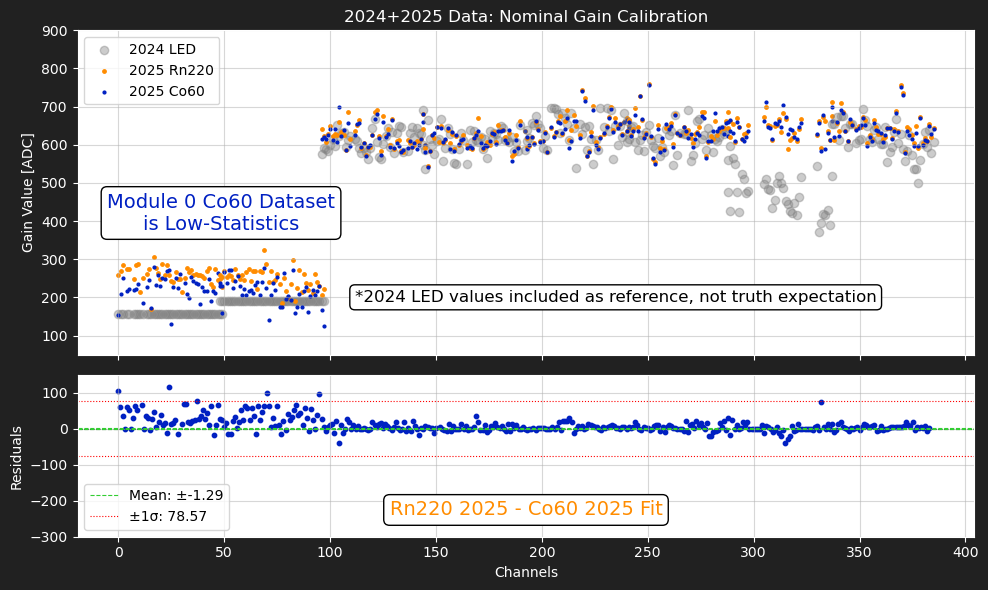

In [12]:

# --- Calculate residuals (difference between old and new values)
residuals = []
residuals2 = []
for adc in original_list:
    #residual = (gains_2024[2,adc, :]) - gains_2024[3,adc, :]
    residual = (1/gain_array[adc, :]) - gains_2024[3,adc, :]
    #residual2 = (1/gain_array[adc, :]) - gains_2024[2,adc, :]
    residual2 = (gains_2024[4,adc, :]*new_dead_array[adc,:]) - gains_2024[5,adc, :]*new_dead_array[adc,:]
    residuals.append(residual)
    residuals2.append(residual2)

residuals = np.concatenate(residuals)  # Shape: (384,)
residuals2 = np.concatenate(residuals2)  # Shape: (384,)
#print(residuals)

# --- Create figure with two subplots
fig, (ax_main, ax_resid) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Plot main gain calibration values
original_list = [0,1,2,3,4,5,6,7]
for adc in original_list:
    factor = adc * 48
    x_vals = np.linspace(factor, factor + 49, 48)

    ax_main.scatter(x_vals, 1/gain_array[adc, :]*new_dead_array[adc,:], color='grey', alpha=0.4, label='2024 LED' if adc == 0 else None)
    #ax_main.scatter(x_vals, gains_2024[0, adc, :], color='coral', alpha=0.4, label='2024 DC Refit' if adc == 0 else None)
    #ax_main.scatter(x_vals, gains_2024[1, adc, :]*new_dead_array[adc,:], s=12, color='deepskyblue', label='2024 DC' if adc == 0 else None)
    #ax_main.scatter(x_vals, gains_2024[2, adc, :], s=6, color='k', label='2024 DC \nFiltered' if adc == 0 else None)
    #ax_main.scatter(x_vals, gains_2024[3, adc, :]*new_dead_array[adc,:], s=6, color='r', label='2025 Rn 25tick' if adc == 0 else None)
    ax_main.scatter(x_vals, gains_2024[4, adc, :]*new_dead_array[adc,:], s=6, color='darkorange', label='2025 Rn220' if adc == 0 else None)
    ax_main.scatter(x_vals, gains_2024[5, adc, :]*new_dead_array[adc,:], s=4, color='#0020C2', label='2025 Co60' if adc == 0 else None)


ax_main.set_ylabel("Gain Value [ADC]", color='white')
ax_main.set_ylim(50, 900)
ax_main.set_title("2024+2025 Data: Nominal Gain Calibration", color='white')
fig.patch.set_facecolor('#212121')
ax_main.tick_params(colors='white')
for spine in ax_main.spines.values():
    spine.set_color('white')
ax_main.grid(True, alpha=0.5)
ax_main.legend(loc='upper left')

# --- Plot residuals
channel_indices = np.arange(384)
# Assign colors per 96-channel block
color_map = ['limegreen'] * 96 + ['mediumslateblue'] * 96 + ['salmon'] * 96 + ['orange'] * 96
#ax_resid.scatter(channel_indices, residuals, c='r', s=10, marker='s')
#ax_resid.scatter(channel_indices, residuals2, c='deepskyblue', s=10, marker='o')
ax_resid.scatter(channel_indices, residuals2, c='#0020C2', s=10, marker='o')
#ax_resid.scatter(channel_indices, residuals - residuals2, c='k', s=8, marker='o')
#print("Offset:",np.mean(residuals - residuals2)/600)

# Optional: add mean & std lines
print(np.mean(residuals[96:]))
mean_resid = np.mean(residuals2[96:][np.abs(residuals[96:]) < 100])
std_resid = np.std(residuals2[96:][np.abs(residuals[96:]) < 100])
ax_resid.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_resid.axhline(mean_resid, color='limegreen', linestyle='--', linewidth=0.8, label=f'Mean: ±{mean_resid:.2f}')
ax_resid.axhline(-1*mean_resid, color='limegreen', linestyle='--', linewidth=0.8)
ax_resid.axhline(mean_resid + std_resid, color='red', linestyle=':', linewidth=0.8, label=f'±1σ: {std_resid:.2f}')
ax_resid.axhline(-1*mean_resid - std_resid, color='red', linestyle=':', linewidth=0.8)

ax_resid.set_xlabel("Channels", color='white')
ax_resid.set_ylabel("Residuals", color='white')
ax_resid.set_ylim(-300, 150)
ax_resid.tick_params(colors='white')
for spine in ax_resid.spines.values():
    spine.set_color('white')
#ax_resid.grid(True, alpha=0.5)
ax_resid.legend(loc='lower left')
ax_resid.grid(True, alpha=0.5)


textstr = f'*2024 LED values included as reference, not truth expectation'
#textstr = f'Particle Type: protons\nVertex in 2x2'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax_main.text(
    0.60, 0.20, textstr,
    transform=ax_main.transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='center',
    bbox=props
)
textstr2 = f'Module 0 Co60 Dataset\nis Low-Statistics'
#textstr = f'Particle Type: protons\nVertex in 2x2'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax_main.text(
    0.16, 0.50, textstr2,
    transform=ax_main.transAxes,
    fontsize=14,
    color='#0020C2',
    verticalalignment='top',
    horizontalalignment='center',
    bbox=props
)
#textstr3 = f'June 2024 LED Fit - October 2025 Radon Fit'
textstr3 = f'Rn220 2025 - Co60 2025 Fit'
#textstr = f'Particle Type: protons\nVertex in 2x2'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax_resid.text(
    0.5, 0.165, textstr3,
    transform=ax_resid.transAxes,
    fontsize=14,
    color='darkorange',
    verticalalignment='center',
    horizontalalignment='center',
    bbox=props
)


plt.tight_layout()
plt.show()
